# Assignment 2 · the audio ladder, modelled

*Every rung of the audio specification as a few lines of Python, run on real recorded vowels, so that you can
see what each block does to the numbers before you build it in SystemVerilog, and predict what the demo probes
will do to your design.*

The recordings are from Hillenbrand et al. (1995): 139 speakers (men, women, children) saying twelve vowels in
h-V-d words, 16 kHz. We use four of the vowels, **ee, ah, oo, aw** (the four lanes), trimmed to the held vowel
and resampled to 12 kHz, which is what the Lesson 4 decimator hands the FFT.

> **Where the recordings come from.** On Ed they are already here, mounted read-only at `/course/h95_data`, and
> the first cell finds them. To run this notebook on your own machine, download `A2_audio_modelling.ipynb` and
> `audio_model.py` together (Ed's *Download* of this workspace gives you both) and put the dataset, `h95.zip`
> (22 MB, on the Canvas page next to the assignment), in a folder `data/` beside them. Nothing is unzipped; the
> first cell reads it in place, and tells you where it looked if it is missing.

Everything here is *float*. Your hardware is fixed point. The notebook's job is to tell you what the answer
should be; the fixed-point choices (widths, where to truncate) are yours, and the report asks for them (Q2 b).

| Rung | Feature vector | D | Section |
|---|---|---|---|
| R-A1 Pass B | the peak bin | 1 | 3, 5, 6 |
| R-A2 Credit | the energy in 8 bands | 8 | 3, 5, 5b |
| R-A3 Distinction | the 8 band energies ÷ their total | 8 | 3, 5b |
| R-A4 High Distinction | 24 log-Mel energies | 24 | 3a, 5, 6 |
| Extras | MFCC | 12 | 3, 6 |

The gate (R-A1, section 2) sits in front of all of them, and the classifier (section 4) behind.

In [1]:
import numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 140, "font.size": 7, "axes.titlesize": 6.5, "lines.linewidth": 1.1, "axes.linewidth": 0.55, "xtick.major.width": 0.55, "ytick.major.width": 0.55})   # Ed shows 950 px
from audio_model import *          # the model of every step, and the classifier as the RTL does it
unpack()                           # finds the 1668 recordings; nothing is unzipped (see source())
print(len(speakers()), "speakers;", "sample rate", FS, "Hz; FFT length", N, "bins of", FS / N, "Hz")

139 speakers; sample rate 12000 Hz; FFT length 1024 bins of 11.71875 Hz


## 1. A vowel is a note with a shape

Load one man's *ee* and *ah*. Same speaker, same pitch more or less: what differs is the **envelope** over the
harmonics, the formants. That envelope is what a vowel *is*; the pitch is just which harmonics happen to sample it.

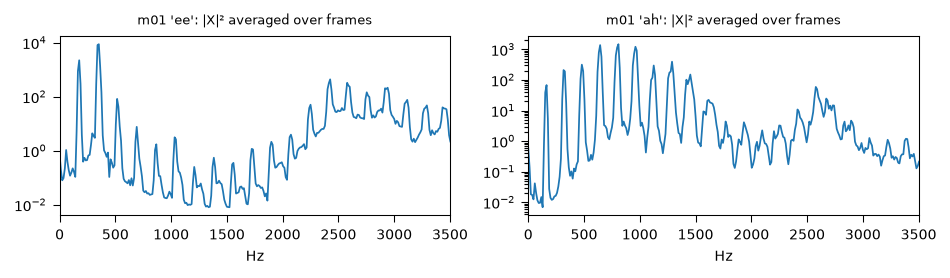

In [2]:
spk = "m01"
fig, ax = plt.subplots(1, 2, figsize=(6.8, 2))
for a, v in zip(ax, ("ee", "ah")):
    x = load(f"{spk}{VOWELS[v]}")
    P = power_spectrum(frames(x, HOP))
    f = np.arange(N // 2 + 1) * FS / N
    a.semilogy(f[:300], P.mean(axis=0)[:300], lw=0.9); a.set_title(f"{spk} '{v}': |X|² averaged over frames")
    a.set_xlabel("Hz"); a.set_xlim(0, 3500)
plt.tight_layout(); plt.show()

## 2. The gate, and the level in dB (R-A1)

The gate decides when there is a voice worth classifying. Three things happen once per 48 kHz sample, and each
is a subtract, a shift and an add:

- the **level** `s`: a fast leaky average of |x| (2⁻⁸ per sample, about 5 ms);
- the **noise floor** `nf`: a *minimum tracker*. It follows `s` **down** quickly (2⁻¹¹, 40 ms) and **up** slowly
  (2⁻¹⁵, 0.7 s), and 16 times slower still while the gate is open. The quiet moments between words pull it down;
  a held note cannot pull it up and close the gate on itself. At reset it starts at ⅛ of full scale, so the gate
  stays closed until the room has been heard;
- the **gate**: open when `s > K · nf`, with K = 4 (12 dB): the *margin*.

HEX1..0 show the level in dB, 20·log₁₀(s) relative to one LSB, and in hardware there is no logarithm: the
position of the leading one of `s` is log₂ to the integer (6 dB per bit) and the three bits below it are the
fraction. The display is updated every 2¹³ samples (0.17 s) so that it can be read.

Try it on a vowel with room noise pasted in front and behind. Then change `K`, and set `hold_sh=0` to see
what the floor does when a note is held.

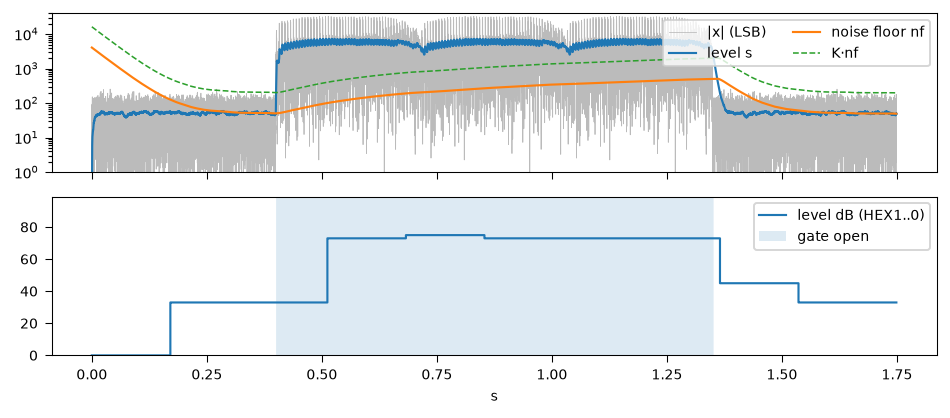

gate open for 0.95 s of 1.75 s;  level shown while open 73 dB, the room 33 dB


In [3]:
from scipy.signal import resample_poly
x = np.tile(load(f"{spk}{VOWELS['ah']}"), 3)                            # hold the vowel for about a second
noise = 0.002 * np.random.default_rng(0).standard_normal(int(0.4 * FS))
sig48 = resample_poly(np.concatenate([noise, x, noise]), 4, 1)          # the gate runs on the raw 48 kHz samples
s, nf, level_db, open_ = gate(sig48, K=4.0)
t = np.arange(len(sig48)) / 48000
fig, ax = plt.subplots(2, 1, figsize=(6.8, 3.0), sharex=True)
ax[0].plot(t, np.abs(sig48) * 32768, color="#bbb", lw=0.4, label="|x| (LSB)"); ax[0].plot(t, s, label="level s")
ax[0].plot(t, nf, label="noise floor nf"); ax[0].plot(t, 4 * nf, "--", lw=0.8, label="K·nf")
ax[0].set_yscale("log"); ax[0].set_ylim(1, 4e4); ax[0].legend(loc="upper right", ncol=2)
ax[1].step(t, level_db, where="post", label="level dB (HEX1..0)"); ax[1].fill_between(t, 0, 99 * open_, alpha=0.15, label="gate open")
ax[1].legend(loc="upper right"); ax[1].set_xlabel("s"); ax[1].set_ylim(0, 99)
plt.tight_layout(); plt.show()
print(f"gate open for {open_.mean() * len(sig48) / 48000:.2f} s of {len(sig48) / 48000:.2f} s;  "
      f"level shown while open {int(np.median(level_db[open_]))} dB, the room {int(np.median(level_db[~open_]))} dB")

## 3. Five ways to describe one spectrum: the rungs

Each rung turns the 513 numbers of |X_k|² into a short feature vector of *D* numbers. Same input frame, five
descriptions. Run the cell and look at what survives in each.

| Rung | Feature | D | What it is | What it throws away |
|---|---|---|---|---|
| Pass | peak bin | 1 | the loudest bin of |X_k|² | everything but the pitch |
| Credit | 8 bands | 8 | the energy in 8 equal bands of 64 bins | the pitch, mostly |
| Distinction | 8 bands ÷ total | 8 | the same, each divided by their sum | the volume too |
| HD | log-Mel | 24 | log₂ of 24 Mel-spaced triangular filters, minus the mean | the volume *and* the microphone gain; the harmonic ripple matters less |
| Extras | MFCC | 12 | DCT of the log-Mel, c₁…c₁₂ | the fine harmonic ripple; keeps the envelope's shape |

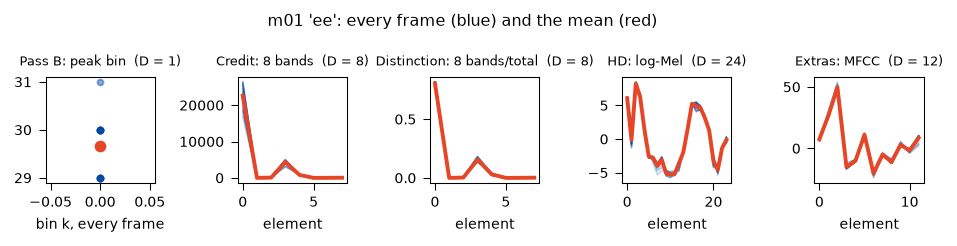

In [4]:
P = power_spectrum(frames(load(f"{spk}{VOWELS['ee']}"), HOP))
fig, ax = plt.subplots(1, 5, figsize=(6.8, 1.7))
for a, (name, fn) in zip(ax, FEATURES.items()):
    F = fn(P)
    mk = "o" if F.shape[1] == 1 else None                                # D = 1: one point per frame, so draw markers
    a.plot(F.T, color="#0148A4", alpha=0.25, lw=0.8, marker=mk, ms=3); a.plot(F.mean(axis=0), color="#E64626", lw=2, marker=mk, ms=5)
    a.set_title(f"{RUNG[name]}: {name}  (D = {F.shape[1]})"); a.set_xlabel("element" if F.shape[1] > 1 else "bin k, every frame")
plt.suptitle(f"{spk} 'ee': every frame (blue) and the mean (red)"); plt.tight_layout(); plt.show()

### 3a. The Mel filter bank

Twenty-four triangles, narrow at low frequencies where the formants that separate vowels live, wide at high
ones. Each bin belongs to two triangles with fractional weights; in hardware that is a weight ROM walked once per
frame with one multiplier. Change `fmin`, `fmax` or the count and re-run the experiments in section 5.

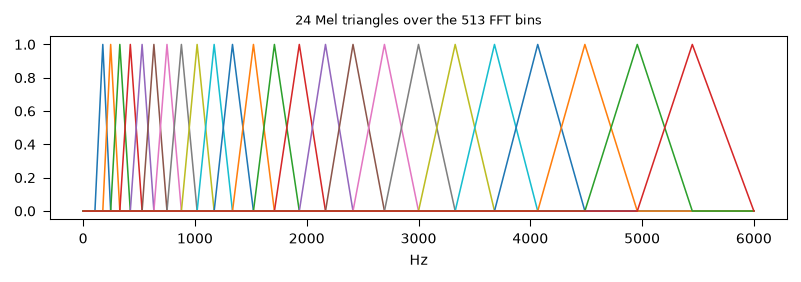

weights per bin (non-zero entries in the ROM): 929


In [5]:
Wm = mel_bank(nf=24, fmin=100, fmax=6000)
f = np.arange(N // 2 + 1) * FS / N
plt.figure(figsize=(6.8, 1.7)); plt.plot(f, Wm.T, lw=0.8); plt.xlabel("Hz"); plt.title("24 Mel triangles over the 513 FFT bins"); plt.show()
print("weights per bin (non-zero entries in the ROM):", int((Wm > 0).sum()))

## 4. The classifier, exactly as the RTL does it

Nearest template by the **sum of absolute differences** (SAD), a few templates per vowel, a **reject** when the
nearest is not clearly nearer than the runner-up (d₁/d₂ > ρ), and a **majority vote** over the last M accepted frames.
`make_templates` is what `train_templates.py` does with the feature vectors you capture from the board with
SignalTap (the enrolment slide); `classify` is `classifier.sv`.

In [6]:
feature = "log-Mel"
train = {v: features_for(spk, v, feature)[: 12] for v in CLASSES}          # enrol: the first 12 frames (0.2 s) of each vowel
T = make_templates(train, nt=4)
for v in CLASSES:
    F = features_for(spk, v, feature)[12:]                                  # test: the rest
    raw, voted, conf = classify(F, T, rho=0.9, M=5)
    print(f"sang {v}:  per-frame {[r or '-' for r in raw][:12]} ...  voted at the end: {voted[-1]}   (rejected {sum(r is None for r in raw)}/{len(raw)})")

sang ee:  per-frame ['ee', 'ee', 'ee', 'ee', 'ee', 'ee', 'ee', 'ee', 'ee', 'ee', 'ee', 'ee'] ...  voted at the end: ee   (rejected 0/12)
sang ah:  per-frame ['ah', 'ah', 'ah', 'ah', 'ah', 'ah', 'ah', 'ah', 'ah', 'ah'] ...  voted at the end: ah   (rejected 0/10)
sang oo:  per-frame ['oo', 'oo', 'oo', 'oo', 'oo', 'oo', 'oo'] ...  voted at the end: oo   (rejected 0/7)
sang aw:  per-frame ['aw', 'aw', 'aw', 'aw', 'aw', '-', 'ah', 'ah', 'ah', 'ah', 'ah'] ...  voted at the end: ah   (rejected 1/11)


## 5. The experiments the demo probes are made of

`experiment(train_speakers, test_speakers, feature)` enrols on some speakers and tests on others, one recording at a
time with the vote restarting for each (that is one utterance at the demo). It returns the per-frame confusion
matrix (rejects in the last column), the per-utterance voted confusion, and the reject rate.

Five situations, all five features. This takes a minute or two.

In [7]:
men = speakers("m"); women = speakers("w"); kids = speakers("b") + speakers("g")
situations = {                                                     # 40 utterances each (10 speakers x 4 vowels)
    "same voices (enrol first 60 % of each)":  dict(train_spk=men[:10], test_spk=men[:10], split_same=True),
    "other men (5 men enrolled)":              dict(train_spk=men[:5], test_spk=men[10:20]),
    "women on men's templates":                dict(train_spk=men[:5], test_spk=women[:10]),
    "children on men's templates":             dict(train_spk=men[:5], test_spk=kids[:10]),
    "10 mixed voices enrolled, 10 new":        dict(train_spk=men[:5] + women[:5], test_spk=men[5:10] + women[5:10]),
}
print(f"{'':40s}" + "".join(f"{r:>14s}" for r in FEATURES))
print(f"{'':40s}" + "".join(f"{RUNG[r]:>14s}" for r in FEATURES))
for name, kw in situations.items():
    row = []
    for feature in FEATURES:
        Mf, Mv, rej = experiment(feature=feature, rho=0.9, **kw)
        row.append(f"{100 * accuracy(Mv):4.0f} % ({100 * rej:2.0f})")
    print(f"{name:40s}" + "".join(f"{r:>14s}" for r in row))
print("\nutterance accuracy after the vote (frames rejected, %). Chance is 25 %.")

                                              peak bin       8 bands 8 bands/total       log-Mel          MFCC
                                                Pass B        Credit   Distinction            HD        Extras
same voices (enrol first 60 % of each)       55 % ( 0)     65 % ( 7)     80 % ( 7)     90 % ( 4)     90 % ( 7)
other men (5 men enrolled)                   57 % (12)     70 % ( 7)     72 % ( 4)     85 % (12)     92 % (14)
women on men's templates                     52 % ( 5)     57 % (11)     78 % ( 9)     65 % (18)     68 % (20)
children on men's templates                  48 % ( 4)     65 % (11)     75 % (17)     60 % (17)     65 % (16)
10 mixed voices enrolled, 10 new             50 % ( 0)     75 % (10)     78 % ( 4)     75 % (21)     72 % (21)

utterance accuracy after the vote (frames rejected, %). Chance is 25 %.


Read the first two rows across: the order holds up the ladder, and the richer features recognise voices they have
never heard. Now read the women's and children's rows: on **five men's** templates, the coarse bands do as well as
the Mel features or better. Fine features learn the enrolled voices' formants precisely, and a different vocal
tract has its formants elsewhere; no feature fixes that. Two lessons for the demo: enrol on the people who will
speak, and MFCC does **not** beat log-Mel on other people, which is why it is an Extra and not a rung. What the
Mel features buy is in sections 5b and 6.

**Report material.** The demo asks which vowels you recorded, what changed as you moved up the rungs, and what
failed along the way (probe 7). Change the situation here (enrol on yourself twice, on a friend, at another pitch),
change ρ, M, the number of templates, the band edges, and *keep the numbers*.

### 5b. The loudness probe: "the same vowel, twice as loud" (R-A2 against R-A3)

At the demo the tutor asks for the same vowel twice as loud (probe 5), and from twice the distance (probe 6).
Both scale every sample by a constant: ×2 is +6 dB, ×4 in |X_k|². Enrol at one loudness and test at another, on
the same voices:

In [8]:
print(f"{'test recordings scaled by':40s}" + "".join(f"{r:>14s}" for r in FEATURES))
for gain in (0.5, 1.0, 2.0, 4.0):
    row = []
    for feature in FEATURES:
        Mf, Mv, rej = experiment(men[:10], men[:10], feature, split_same=True, rho=0.9, gain=gain)
        row.append(f"{100 * accuracy(Mv):4.0f} % ({100 * rej:2.0f})")
    print(f"x{gain:<5g} ({20 * np.log10(gain):+3.0f} dB){'':25s}" + "".join(f"{r:>14s}" for r in row))

test recordings scaled by                     peak bin       8 bands 8 bands/total       log-Mel          MFCC
x0.5   ( -6 dB)                              55 % ( 0)     30 % (11)     80 % ( 7)     90 % ( 4)     90 % ( 7)
x1     ( +0 dB)                              55 % ( 0)     65 % ( 7)     80 % ( 7)     90 % ( 4)     90 % ( 7)
x2     ( +6 dB)                              55 % ( 0)     40 % (15)     80 % ( 7)     90 % ( 4)     90 % ( 7)
x4     (+12 dB)                              55 % ( 0)      8 % (71)     80 % ( 7)     90 % ( 4)     90 % ( 7)


Raw band energies scale with the volume, so at another loudness the nearest template is whichever was recorded at
the nearest loudness, or none: that is the Credit rung's limitation and what the Distinction rung fixes with one
division. The peak bin never cared about loudness (it is a position, not a size), and log-Mel minus its mean is
loudness-free by construction: ×4 in every band is +2 in every log₂, and the mean takes it out.

The division is the catch in hardware. Section 8 has two ways round it, and `"8 bands/pow2"` in
`EXTRA_FEATURES` models the cheap one.

## 6. The pitch probe: "say it on a clearly higher note"

At the demo a tutor asks for the same vowel at a higher pitch (probe 3 at Pass, probe 6 at HD). Synthetic vowels
make this exact: the same formant envelope with harmonics of a different f₀. Enrol at 150 Hz, test from 110 to 300 Hz.

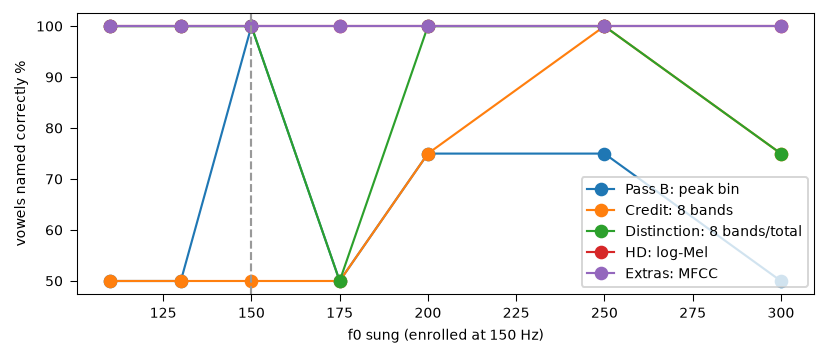

In [9]:
pe = pitch_experiment(f0_enrol=150, rho=0.9)
plt.figure(figsize=(6.8, 2.6))
for feature, rows in pe.items():
    f0s, accs = zip(*rows); plt.plot(f0s, 100 * np.array(accs), "o-", label=f"{RUNG[feature]}: {feature}")
plt.axvline(150, color="#999", ls="--"); plt.xlabel("f0 sung (enrolled at 150 Hz)"); plt.ylabel("vowels named correctly %"); plt.legend(); plt.show()

The peak bin follows the note, so it fails the moment the pitch changes: that is the *point* of it, and the first
probe. Eight equal bands wobble as harmonics cross the band edges, divided by the total or not. The Mel features hold.

## 7. Two things to try before you write RTL

1. **Rectangular vs Hamming window** (`window=False` in `experiment`): how much do the 8 bands lose?
2. **The reject rule**: sweep ρ from 0.6 to 1.0 on one situation and plot accuracy-on-accepted against the reject
   rate. Where would you put it for the demo, where a wrong key is worse than a missed one?

## 8. From here to fixed point

Every function above has a hardware twin. The numbers that matter for your widths:

- |X_k|² from a 16-bit FFT is up to 33 bits; a band sum over 64 bins needs 6 more. The classifier takes 16-bit
  features: decide which 16 bits of the sum you keep, and say so in the report.
- **÷ total** without a divider: either shift every band right by the position of the total's leading one (÷ the
  power of two just below the total, so the result is right to within a factor of two: the cell below says whether
  that is good enough), or divide properly one bit per clock (a frame is 1.5 million FFT clocks; 8 bands × 16 clocks
  is nothing).
- log₂ from the leading-one position is exact to the integer; the next few bits after the leading one give the
  fraction (worst error 0.09 with none of them: about 0.5 dB).
- Extras, MFCC: the DCT cosines are in [−1, 1], 16-bit signed with 15 fraction bits is plenty; 12 × 24 = 288
  multiply-adds per frame, one multiplier.

Compare your hardware's feature vector (a SignalTap capture of `feature`: the enrolment slide) with `features_for`
on the same recording; the difference is your quantisation, and the report asks for that number.

In [10]:
for name in ("8 bands/total", "8 bands/pow2"):                            # exact division vs a shift by the leading one
    Mf, Mv, rej = experiment(men[:10], men[:10], name, split_same=True, rho=0.9, gain=2.0)
    print(f"{name:14s} twice as loud: {100 * accuracy(Mv):3.0f} %  ({100 * rej:2.0f} % of frames rejected)")

8 bands/total  twice as loud:  80 %  ( 7 % of frames rejected)
8 bands/pow2   twice as loud:  80 %  (18 % of frames rejected)
